In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers.legacy import Optimizer
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2

from tensorflow.keras.optimizers import AdamW
import pickle


2025-04-17 09:03:05.916435: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-17 09:03:05.966061: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-17 09:03:05.966185: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-17 09:03:05.967379: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-17 09:03:05.974309: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-17 09:03:05.974907: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
counts = pd.read_csv('/work/counts_pred.csv')
X = pd.read_csv('/work/preprocessed.csv')
X['No Of Withdrawals'] = StandardScaler().fit_transform(counts)

In [3]:

y = pd.read_csv('/work/target.csv')['Total amount Withdrawn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_norm = (y_train - y_train.min()) / (y_train.max() - y_train.min())
y_test_norm = (y_test - y_test.min()) / (y_test.max() - y_test.min())


In [4]:
def quantile_loss(q):
    """Custom loss function for quantile regression."""
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
    return loss


In [5]:
def run_ann(X_train, y_train, q, validation_split=0.1):

    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        layers.Dense(128, activation="relu"),
        Dropout(0.3),
        layers.Dense(32, activation="relu"),
        Dropout(0.3),
        BatchNormalization(),
        layers.Dense(1, activation="softplus"),
    ])

    optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-2)

    model.compile(optimizer=optimizer, loss=quantile_loss(q=q), metrics=['mae'])
    history = model.fit(X_train, y_train, epochs=200, validation_split=validation_split, batch_size = 32)
    

    return model, history


In [19]:
model_amt_975, history_975 = run_ann(X_train, y_train_norm, q=0.975, validation_split=0.1)


Epoch 1/200
286/286 [==============================] - 2s 2ms/step - loss: 0.0270 - mae: 0.6470 - val_loss: 0.0126 - val_mae: 0.5034
Epoch 2/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0141 - mae: 0.4619 - val_loss: 0.0083 - val_mae: 0.3310
Epoch 3/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0098 - mae: 0.3267 - val_loss: 0.0066 - val_mae: 0.2629
Epoch 4/200
286/286 [==============================] - 0s 2ms/step - loss: 0.0079 - mae: 0.2656 - val_loss: 0.0063 - val_mae: 0.2521
Epoch 5/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0069 - mae: 0.2343 - val_loss: 0.0055 - val_mae: 0.2162
Epoch 6/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0063 - mae: 0.2142 - val_loss: 0.0051 - val_mae: 0.2051
Epoch 7/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0058 - mae: 0.2006 - val_loss: 0.0044 - val_mae: 0.1739
Epoch 8/200
286/286 [==============================] - 1s 2ms/step - 

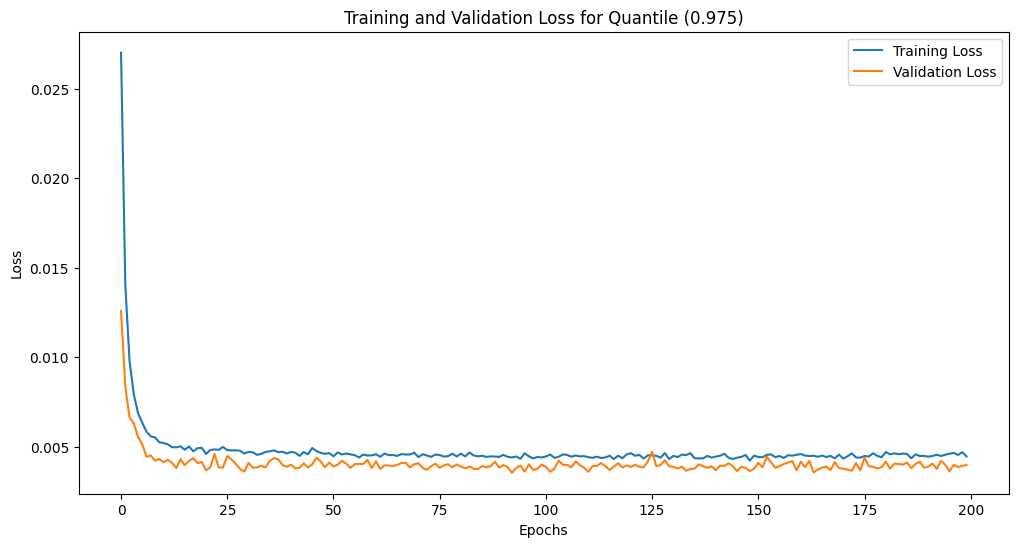

In [20]:

plt.figure(figsize=(12,6))
plt.plot(history_975.history['loss'], label='Training Loss')
plt.plot(history_975.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss for Quantile (0.975)')
plt.show()

In [21]:
model_amt_975, history_975 = run_ann(X_train, y_train_norm, q=0.975, validation_split=0.0)

Epoch 1/200
317/317 [==============================] - 2s 2ms/step - loss: 0.0278 - mae: 0.6563
Epoch 2/200
317/317 [==============================] - 0s 2ms/step - loss: 0.0127 - mae: 0.4303
Epoch 3/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0084 - mae: 0.2811
Epoch 4/200
317/317 [==============================] - 0s 2ms/step - loss: 0.0067 - mae: 0.2303
Epoch 5/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0062 - mae: 0.2059
Epoch 6/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0059 - mae: 0.1989
Epoch 7/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0056 - mae: 0.1848
Epoch 8/200
317/317 [==============================] - 0s 2ms/step - loss: 0.0054 - mae: 0.1770
Epoch 9/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0052 - mae: 0.1723
Epoch 10/200
317/317 [==============================] - 0s 1ms/step - loss: 0.0051 - mae: 0.1677
Epoch 11/200
317/317 [=================

In [25]:
y_pred_amt_ub = model_amt_975.predict(X_test).flatten()
y_pred_amt_ub = (y_pred_amt_ub * (y_test.max() - y_test.min()) + y_test.min()).astype('int')
# y_pred_amt_ub = (y_pred_amt_ub * y_test.std() + y_test.mean()).astype('int')

80/80 [==============================] - 0s 1ms/step


In [27]:
below_ub = (y_pred_amt_ub >= y_test).sum() / len(y_test)
print('Points Below Upper Bound:', below_ub)

Points Below Upper Bound: 0.9767258382642998


In [29]:
model_amt_025, history_025 = run_ann(X_train, y_train_norm, q=0.025, validation_split=0.1)


Epoch 1/200
286/286 [==============================] - 2s 3ms/step - loss: 0.1542 - mae: 0.2414 - val_loss: 0.0068 - val_mae: 0.1297
Epoch 2/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0145 - mae: 0.1855 - val_loss: 0.0051 - val_mae: 0.1967
Epoch 3/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0074 - mae: 0.2062 - val_loss: 0.0051 - val_mae: 0.1999
Epoch 4/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0064 - mae: 0.2040 - val_loss: 0.0049 - val_mae: 0.1929
Epoch 5/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0060 - mae: 0.2017 - val_loss: 0.0048 - val_mae: 0.1923
Epoch 6/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0056 - mae: 0.1974 - val_loss: 0.0048 - val_mae: 0.1899
Epoch 7/200
286/286 [==============================] - 1s 2ms/step - loss: 0.0054 - mae: 0.1907 - val_loss: 0.0046 - val_mae: 0.1823
Epoch 8/200
286/286 [==============================] - 1s 2ms/step - 

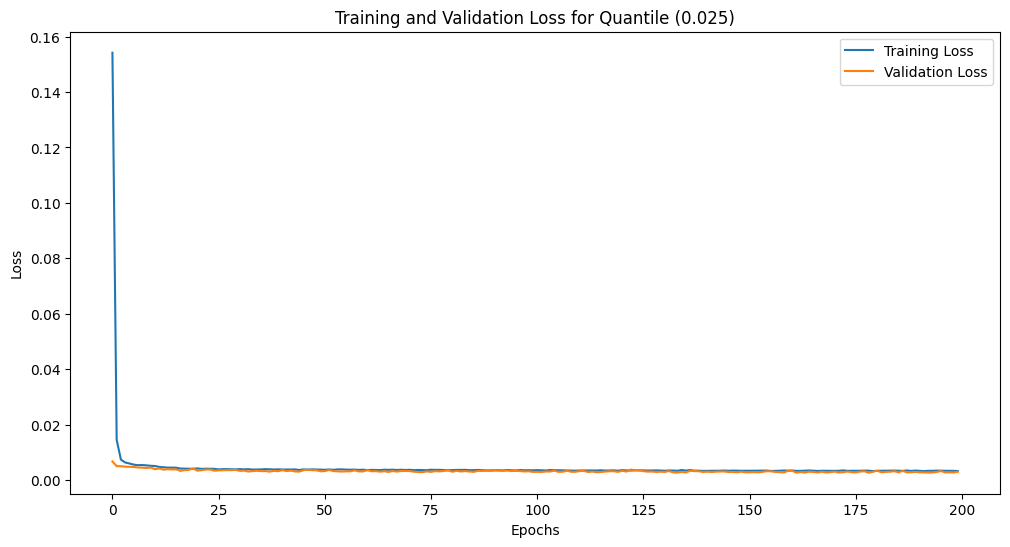

In [30]:
plt.figure(figsize=(12,6))
plt.plot(history_025.history['loss'], label='Training Loss')
plt.plot(history_025.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss for Quantile (0.025)')
plt.show()

In [31]:
model_amt_025, history_025 = run_ann(X_train, y_train_norm, q=0.025, validation_split=0.0)


Epoch 1/200
317/317 [==============================] - 2s 2ms/step - loss: 0.1514 - mae: 0.2571
Epoch 2/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0141 - mae: 0.2087
Epoch 3/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0080 - mae: 0.2299
Epoch 4/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0072 - mae: 0.2318
Epoch 5/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0066 - mae: 0.2261
Epoch 6/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0063 - mae: 0.2241
Epoch 7/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0062 - mae: 0.2125
Epoch 8/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0057 - mae: 0.2041
Epoch 9/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0054 - mae: 0.1889
Epoch 10/200
317/317 [==============================] - 1s 2ms/step - loss: 0.0054 - mae: 0.1894
Epoch 11/200
317/317 [=================

In [32]:

y_pred_amt_lb = model_amt_025.predict(X_test).flatten()
y_pred_amt_lb = (y_pred_amt_lb * (y_test.max() - y_test.min()) + y_test.min()).astype('int')
# y_pred_amt_lb = (y_pred_amt_lb * y_test.std() + y_test.mean()).astype('int')

mean_pred_amt = (y_pred_amt_lb + y_pred_counts_ub) / 2

80/80 [==============================] - 0s 1ms/step


In [35]:
below_lb = (y_pred_amt_lb >= y_test).sum() / len(y_test)
print('Points Below Lower Bound:', below_lb)

Points Below Lower Bound: 0.010650887573964497


In [37]:
def compute_picp(y_lower, y_upper, y_true):
    return np.mean(np.logical_and(y_true >= y_lower, y_true <= y_upper))

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def cwc_loss_numpy(y_lower, y_upper, y_true, gamma=50, eta=50, mu=0.95):
    picp = compute_picp(y_lower, y_upper, y_true)
    pinrw = compute_pinrw(y_lower, y_upper, y_true)
    penalty = np.exp(eta * (mu - picp))
    cwc = pinrw * (1 + gamma * penalty)
    mpiw = np.mean(y_upper - y_lower)

    return cwc, picp, mpiw, pinrw

In [39]:

cwc, picp, mpiw, pinrw = cwc_loss_numpy(y_pred_amt_lb, y_pred_amt_ub, y_test, gamma=50, eta=50, mu=0.95)
outcome = (y_test >= y_pred_amt_lb) & (y_test <= y_pred_amt_ub)

result = pd.DataFrame({'Original': y_test, 'Predicted': mean_pred_amt,
                        'Lower Bound': y_pred_amt_lb, 'Upper Bound': y_pred_amt_ub,
                        'Outcome': outcome})


result.to_csv(f'Results_Quantile_ANN_amt.csv', index=False)


In [41]:
print('PICP: ', picp)
print('PINRW: ', pinrw)
print('CWC: ', cwc)
print('MPIW: ', mpiw)

PICP:  0.9660749506903353
PINRW:  0.28410860714660807
CWC:  6.643144498917749
MPIW:  337701.55581854045


In [43]:
with open('model_amt_975.pkl', 'wb') as f:
    pickle.dump(model_amt_975, f)

with open('model_amt_025.pkl', 'wb') as f:
    pickle.dump(model_amt_025, f)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6c5dcd7e-ee44-459a-9dd6-5c39b2404cb3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>